In [1]:
import time

import numpy as np
import pandas as pd
from multiprocess import Pool

from benchmarking.multiprocessing.functions import evaluate_ar, evaluate_multiplier_iid, evaluate_ma
from bstrapping.synthetic_time_series.moving_average import MovingAverage
from bstrapping.weights.moving_average import MovingAverageWeights, triangle_window

In [2]:
mean = 4  # mean of the time series
alpha = 0.05

# Names of the stochastic processes

# Dependence coefficients of the stochastic processes, i.e. of the moving average processes
dependence_coefficients = [
    np.array([0]),
    np.array([0.5]),
    np.array([0.5 ** i for i in range(1, 3)]),
    np.array([0.5 ** i for i in range(1, 11)]),
    np.array([0.5 ** i for i in range(1, 16)]),
    np.array([0.5 ** i for i in range(1, 21)]),
]

names_dependence_coefficients = [
    "iid",
    "MA(1)",
    "MA(2)",
    "MA(10)",
    "MA(15)",
    "MA(20)",
]

list_name_weights = ['AR',
                     'Multiplier',
                     'MA',
                     ]

In [3]:
sample_size = 1000
index_dependence = 0
bootstrapped_sample_size = 250

time_series = MovingAverage(mean=mean, parameters=dependence_coefficients[index_dependence])
samples = MovingAverage(mean=mean, parameters=dependence_coefficients[index_dependence]).generate_samples(sample_size)

In [4]:
MovingAverage(mean=mean, parameters=dependence_coefficients[index_dependence]).asymptotic_variance

1

# Online multiplier bootstrap

In [5]:
from bstrapping.weights.auto_regressive_weights import AutoRegressiveWeights, generate_recursive_weight
from bstrapping.bootstrap_procedures.weighted_bootstrap import WeightedBootstrap

bootstrap = WeightedBootstrap(samples=samples,
                              weights=AutoRegressiveWeights(samples=samples),
                              number_bootstrap_samples=bootstrapped_sample_size)

1000 samples with dimension 1 were obtained. 

Bootstrapping...


100%|██████████| 250/250 [00:00<00:00, 285.27it/s]


In [6]:
sample_size*bootstrap.bootstrapped_variance

0.7272156135667485

In [7]:
def new_weights_ar(t, old_weights):
    return np.array([generate_recursive_weight(t, V_i, alpha=2 ** (1 / 2) - 1) for V_i in old_weights])

In [8]:
def online_update(new_sample, averages_mean, new_weights, sum_old_weights):
    averages_mean = (sum_old_weights / (sum_old_weights + new_weights)) * averages_mean + 1 / (
            sum_old_weights + new_weights) * new_weights * new_sample
    return averages_mean

In [9]:
duration_ar = []

start_time = time.perf_counter()
old_weights = np.random.normal(loc=1, scale=1, size=bootstrapped_sample_size)
sum_old_weights = old_weights
averages_mean = np.array([samples[0] * old_weights])
end_time = time.perf_counter()
duration_ar.append(end_time - start_time)
# for validation
asy_var = []
for t, sample in enumerate(samples[1:]):
    start_time = time.perf_counter()
    new_weights = new_weights_ar(t + 1, old_weights)
    averages_mean = online_update(sample, averages_mean, new_weights, sum_old_weights)
    sum_old_weights += new_weights
    # for validation

    asy_var.append((t + 1) * np.var(averages_mean))

    old_weights = new_weights
    end_time = time.perf_counter()
    duration_ar.append(end_time - start_time)

<Axes: >

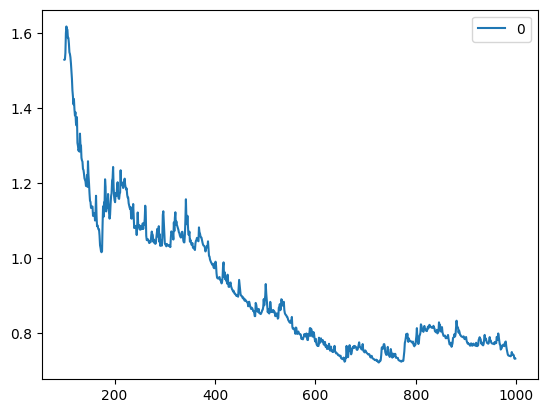

In [10]:
pd.DataFrame(asy_var)[100:].plot()

In [11]:
np.sum(duration_ar)

0.9692005390000142

# IID

In [12]:
def new_weights_iid():
    return np.random.normal(loc=1, scale=1, size=bootstrapped_sample_size)

duration_iid = []
# for validation
asy_var = []
averages_mean = np.zeros(bootstrapped_sample_size)
sum_old_weights = 0
for t, sample in enumerate(samples):
    start_time = time.perf_counter()
    new_weights = new_weights_iid()
    averages_mean = online_update(sample, averages_mean, new_weights, sum_old_weights)
    sum_old_weights += new_weights
    # for validation

    asy_var.append((t + 1) * np.var(averages_mean))

    old_weights = new_weights
    end_time = time.perf_counter()
    duration_iid.append(end_time - start_time)

<Axes: >

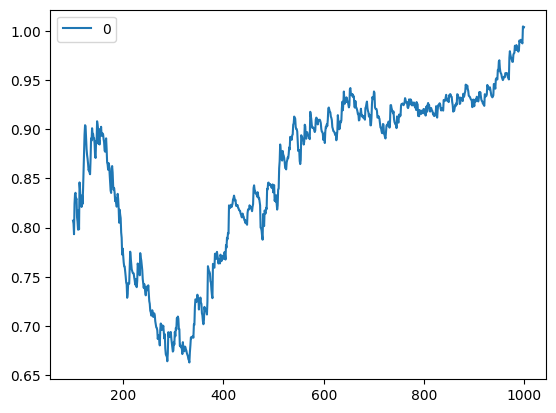

In [13]:
pd.DataFrame(asy_var)[100:].plot()

# MA 

In [14]:
class new_weights_ma_same_block_length:
    def __init__(self, gamma_weights):
        self.gamma_weights = gamma_weights  # to be updated

    def __call__(self, t):
        block_length = int(t ** (1 / 3))  # =l_n page 92 Bühlmann
        return np.sum([
            triangle_window(block_length, j) * self.gamma_weights[t - j]
            for j in range(-block_length, block_length + 1)])


In [15]:
duration_ma = []
# for validation

In [16]:
asy_var = []
for t, sample in enumerate(samples):
    start_time = time.perf_counter()
    if int(t ** (1 / 3)) == int((t + 1) ** (1 / 3)):
        w = new_weights_ma_same_block_length(np.array(gamma_weights).T)
        new_weights = w(t + 1)
        averages_mean = online_update(sample, averages_mean, new_weights, sum_old_weights)
        sum_old_weights += new_weights
        # for validation

        asy_var.append((t + 1) * np.var(averages_mean))

        old_weights = new_weights
    else:
        print(t)
        new_weights_ma_same_block_length.gamma_weights = []
        gamma_weights = []
        averages_mean = []
        for _ in range(bootstrapped_sample_size):
            weights = MovingAverageWeights(samples=samples[:int(((t+1)**(1/3)+1)**3)+2])
            weight = weights()[:t+1]
            gamma_weights.append(weights._gamma_weights)
            averages_mean.append(np.average((1 / np.average(weight) * weight * samples[:t+1])))
        averages_mean = np.array(averages_mean)
        asy_var.append((t + 1) * np.var(averages_mean))

    end_time = time.perf_counter()
    duration_ma.append(end_time - start_time)

0
7
26
64
125
216
343
512
729


<Axes: >

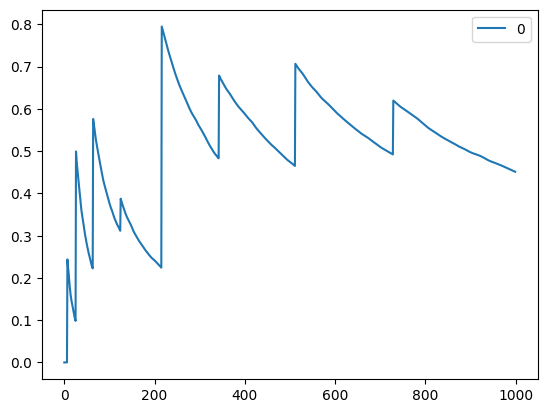

In [17]:
pd.DataFrame(asy_var).plot()